In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [14]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

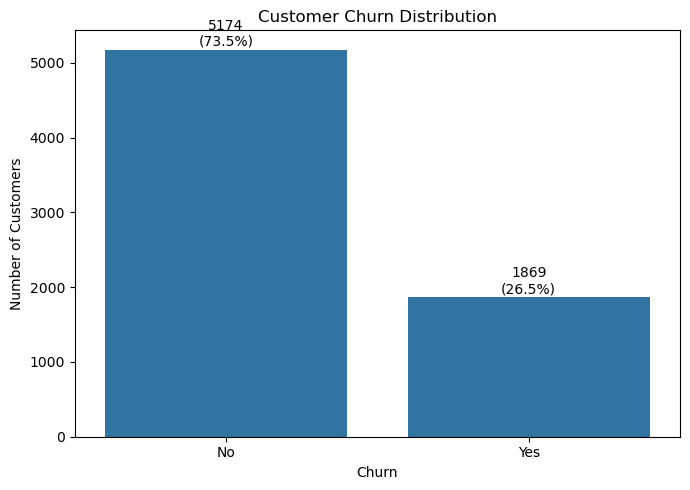

In [16]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(data=df, x='Churn')

total = len(df)

for container in ax.containers:
    for bar in container:
        count = bar.get_height()
        percentage = count / total * 100
        
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            count + 50,
            f'{count:.0f}\n({percentage:.1f}%)',
            ha='center'
        )

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

## Customer Churn Distribution

The dataset contains 7,043 customers. Approximately 73.46% of customers did not churn, while 26.54% of customers churned.

This indicates a class imbalance in the target variable. Since churned customers represent the minority class, class imbalance needs to be considered during model training. SMOTE will later be applied to the training data to address this issue.

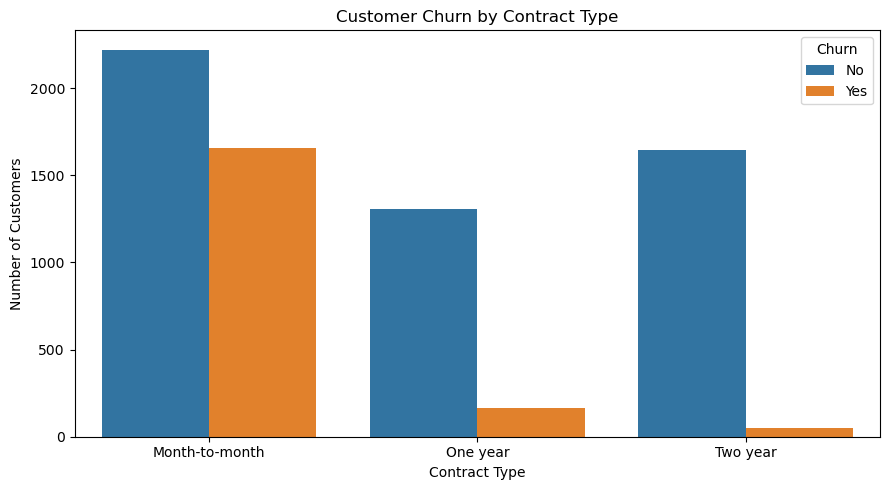

In [17]:
plt.figure(figsize=(9, 5))

ax = sns.countplot(
    data=df,
    x='Contract',
    hue='Churn'
)

plt.title('Customer Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

In [18]:
contract_churn_rate = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn_rate

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


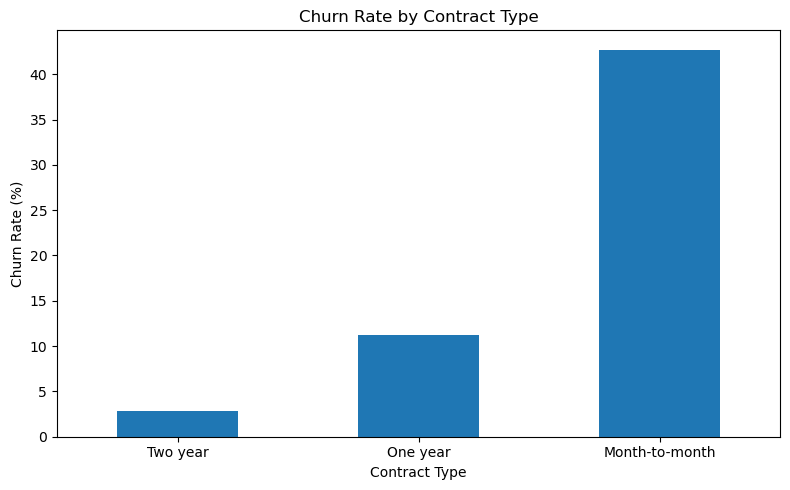

In [19]:
contract_churn_rate['Yes'].sort_values().plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 📌 Insight: Contract Type and Customer Churn

Contract type shows a strong relationship with customer churn.

The churn rate is approximately 42.7% for month-to-month customers, compared with 11.3% for one-year contracts and only 2.8% for two-year contracts.

This indicates that customers with longer-term contracts are considerably less likely to churn.

### 💼 Business Recommendation

The company should focus retention efforts on month-to-month customers and encourage them to move toward longer-term contracts using discounts, loyalty benefits, and personalized contract upgrade offers.

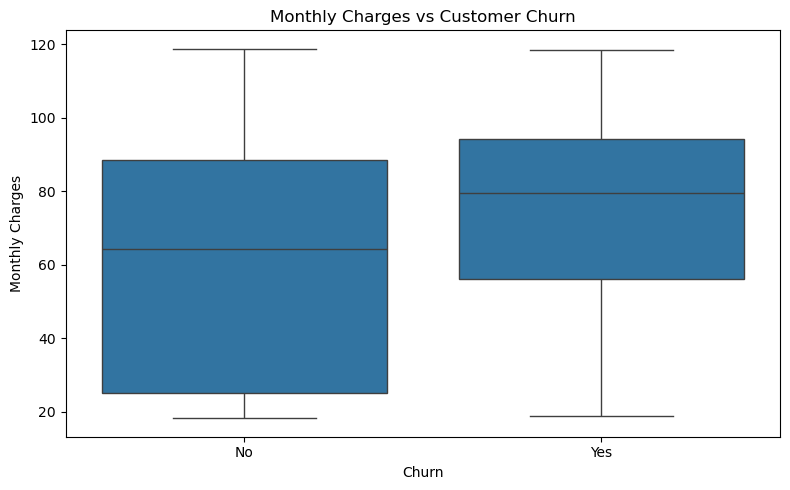

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title('Monthly Charges vs Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.tight_layout()
plt.show()

In [21]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

## 📌 Insight: Monthly Charges and Customer Churn

Customers who churned had an average monthly charge of approximately 74.44, compared with 61.27 for customers who stayed.

This indicates that churned customers were paying approximately 21.5% more per month on average.

Higher monthly charges appear to be associated with increased churn. However, this relationship does not necessarily imply that higher charges directly cause customers to churn.

### 💼 Business Recommendation

The company could identify high-paying customers who are also showing other signs of churn risk and provide personalized plans, discounts, or additional service benefits to improve retention.

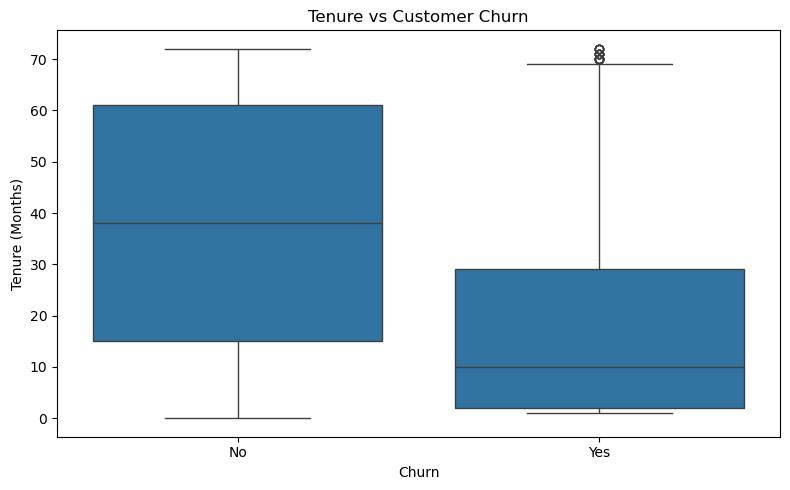

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='tenure'
)

plt.title('Tenure vs Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')

plt.tight_layout()
plt.show()

In [23]:
df.groupby('Churn')['tenure'].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

## 📌 Insight: Customer Tenure and Churn

Customers who churned had an average tenure of approximately 17.98 months, while customers who stayed had an average tenure of approximately 37.57 months.

This indicates that newer customers are considerably more likely to churn than long-term customers.

The boxplot also shows that churned customers are concentrated more heavily toward lower tenure values.

### 💼 Business Recommendation

The company should focus strongly on customer retention during the early stages of the customer lifecycle.

New customers could be targeted with onboarding programs, early loyalty rewards, personalized offers, and proactive customer support to reduce early-stage churn.

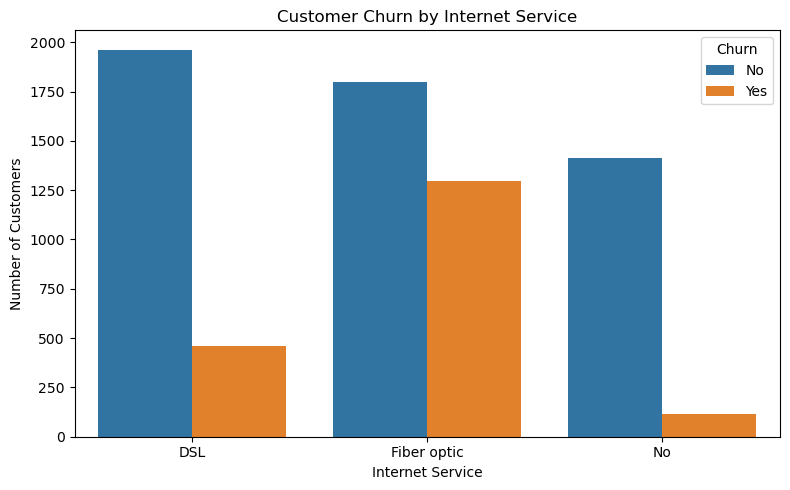

In [24]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='InternetService',
    hue='Churn'
)

plt.title('Customer Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

In [25]:
internet_churn_rate = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

internet_churn_rate

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


## 📌 Insight: Internet Service and Customer Churn

Internet service type shows a strong relationship with customer churn.

Fiber optic customers have the highest churn rate at approximately 41.89%, compared with 18.96% for DSL customers and only 7.40% for customers without internet service.

This indicates that fiber optic customers may represent an important high-risk customer segment.

However, this analysis shows an association and does not prove that fiber optic service directly causes customer churn.

### 💼 Business Recommendation

The company should investigate the pricing, service quality, reliability, technical support, and overall customer experience of fiber optic customers.

Targeted retention offers and proactive support could be used for high-risk fiber optic customers.

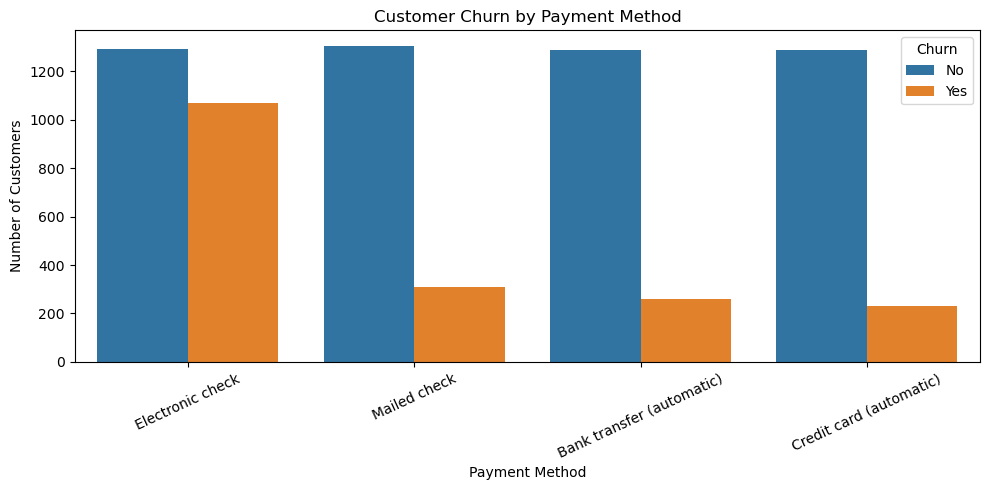

In [26]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='PaymentMethod',
    hue='Churn'
)

plt.title('Customer Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

In [27]:
payment_churn_rate = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

payment_churn_rate

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


## 📌 Insight: Payment Method and Customer Churn

Payment method shows a strong relationship with customer churn.

Electronic check customers have the highest churn rate at approximately 45.29%, compared with 19.11% for mailed check, 16.71% for automatic bank transfer, and 15.24% for automatic credit card payments.

This makes electronic check customers an important high-risk segment for customer retention.

However, this analysis shows an association and does not prove that the payment method itself causes customer churn.

### 💼 Business Recommendation

The company should investigate why electronic check customers have a higher churn rate.

It could encourage customers to use automatic payment methods through incentives, discounts, or simplified payment options.

The company should also analyze electronic-check customers alongside contract type and tenure to identify the underlying reasons for their higher churn.

In [28]:
high_risk = df[
    (df['Contract'] == 'Month-to-month') &
    (df['InternetService'] == 'Fiber optic') &
    (df['PaymentMethod'] == 'Electronic check')
]

high_risk['Churn'].value_counts(normalize=True) * 100

Churn
Yes    60.367253
No     39.632747
Name: proportion, dtype: float64

In [29]:
high_risk.shape

(1307, 21)

## 🔥 High-Risk Customer Segment

A high-risk customer segment was identified by combining three characteristics:

- Month-to-month contract
- Fiber optic internet service
- Electronic check payment

There are 1,307 customers in this segment.

Approximately 60.37% of these customers have churned, compared with an overall churn rate of approximately 26.54%.

This indicates that this customer segment has a substantially higher churn risk than the overall customer base.

### 💼 Business Recommendation

The company should prioritize this segment for proactive retention campaigns.

Potential actions include:

- Personalized retention offers
- Discounts for switching to longer-term contracts
- Incentives for automatic payment methods
- Improved support for fiber optic customers
- Early intervention for customers showing additional churn signals

This analysis identifies an association between these characteristics and churn; it does not establish that any individual characteristic directly causes churn.

In [30]:
df['HighRiskSegment'] = (
    (df['Contract'] == 'Month-to-month') &
    (df['InternetService'] == 'Fiber optic') &
    (df['PaymentMethod'] == 'Electronic check')
)

df.groupby('HighRiskSegment')['Churn'].value_counts(normalize=True) * 100

HighRiskSegment  Churn
False            No       81.171548
                 Yes      18.828452
True             Yes      60.367253
                 No       39.632747
Name: proportion, dtype: float64

In [31]:
df.groupby('HighRiskSegment')['Churn'].value_counts()

HighRiskSegment  Churn
False            No       4656
                 Yes      1080
True             Yes       789
                 No        518
Name: count, dtype: int64

## 📊 High-Risk Segment vs. Remaining Customer Base

A breakdown comparing the high-risk segment (**Month-to-month + Fiber optic + Electronic check**) against all other customers:

- **High-Risk Segment (`True`):** 60.37% Churn rate (789 churned, 518 stayed)
- **Remaining Customers (`False`):** 18.83% Churn rate (1,080 churned, 4,656 stayed)

### 🔑 Key Insight
Customers matching all three high-risk criteria churn at **more than 3× the rate** of the rest of the customer base (60.37% vs. 18.83%).

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Clean & copy dataframe
df_ml = df.copy()

# Drop ID and temporary helper columns that shouldn't be trained on
cols_to_drop = ['customerID', 'HighRiskSegment']
df_ml = df_ml.drop(columns=[c for c in cols_to_drop if c in df_ml.columns])

# 2. Encode Target variable (Churn: Yes -> 1, No -> 0)
df_ml['Churn'] = df_ml['Churn'].map({'Yes': 1, 'No': 0})

# Handle TotalCharges if it's still object type (convert spaces to NaN & fill)
if df_ml['TotalCharges'].dtype == 'object':
    df_ml['TotalCharges'] = pd.to_numeric(df_ml['TotalCharges'].str.strip(), errors='coerce')
    df_ml['TotalCharges'].fillna(df_ml['TotalCharges'].median(), inplace=True)

# 3. One-Hot Encode remaining categorical features
df_encoded = pd.get_dummies(df_ml, drop_first=True)

# 4. Features (X) and Target (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# 5. Train-Test Split (80/20 with stratification to preserve class imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")
print(f"Training class distribution:\n{y_train.value_counts(normalize=True)}")

Training set shape: (5634, 30)
Testing set shape:  (1409, 30)
Training class distribution:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


C:\Users\abhis\AppData\Local\Temp\ipykernel_30688\1326353619.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ml['TotalCharges'].fillna(df_ml['TotalCharges'].median(), inplace=True)
